Duke gjeneruar Diagramin Hapësirë-Kohë...


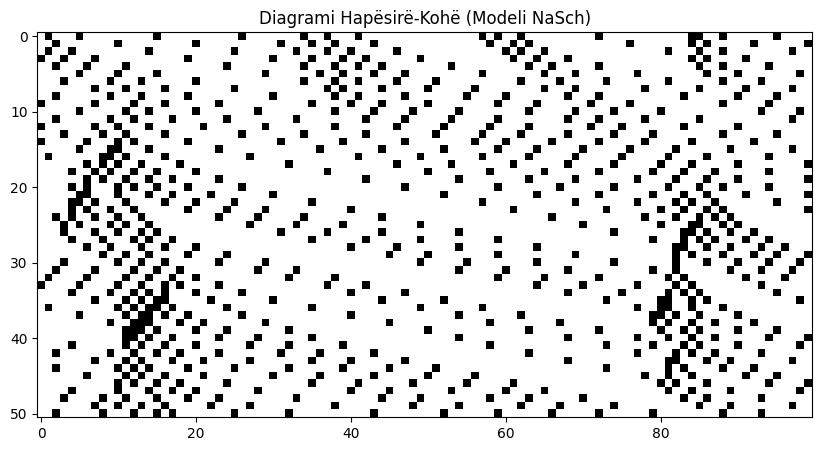

Duke gjeneruar Diagramin Fundamental...


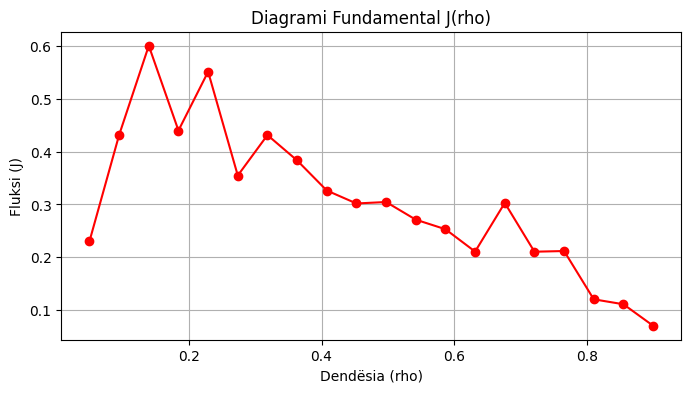

In [6]:
# 1. Instalimi i nevojshëm
!pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

# --- LOGJIKA E PROJEKTIT (E BASHKUAR) ---

def simulate_traffic(length, density, max_velocity, p_slowdown, steps):
    road = -1 * np.ones(length, dtype=int)
    num_cars = int(length * density)
    pos = np.random.choice(length, num_cars, replace=False)
    for p in pos: road[p] = np.random.randint(0, max_velocity + 1)

    history = [road.copy()]
    for _ in range(steps):
        new_road = -1 * np.ones(length, dtype=int)
        for i in range(length):
            if road[i] != -1:
                v = road[i]
                if v < max_velocity: v += 1
                dist = 0
                for j in range(1, length):
                    if road[(i + j) % length] != -1: break
                    dist += 1
                if v > dist: v = dist
                if v > 0 and np.random.rand() < p_slowdown: v -= 1
                new_road[(i + v) % length] = v
        road = new_road
        history.append(road.copy())
    return np.array(history)

# --- EKZEKUTIMI DHE GRAFIKËT ---

L, v_max, p = 100, 5, 0.3
steps = 50

# Grafiku 1: Hapësirë-Kohë
print("Duke gjeneruar Diagramin Hapësirë-Kohë...")
history = simulate_traffic(L, 0.15, v_max, p, steps)
plt.figure(figsize=(10, 5))
plt.imshow(np.where(history >= 0, 1, 0), cmap='binary', aspect='auto')
plt.title("Diagrami Hapësirë-Kohë (Modeli NaSch)")
plt.show()

# Grafiku 2: Fundamental (J-rho)
print("Duke gjeneruar Diagramin Fundamental...")
densities = np.linspace(0.05, 0.9, 20)
fluxes = []
for d in densities:
    h = simulate_traffic(L, d, v_max, p, 50)
    v_avg = np.mean(h[-1][h[-1] >= 0]) if np.any(h[-1] >= 0) else 0
    fluxes.append(d * v_avg)

plt.figure(figsize=(8, 4))
plt.plot(densities, fluxes, 'o-r')
plt.xlabel("Dendësia (rho)")
plt.ylabel("Fluksi (J)")
plt.title("Diagrami Fundamental J(rho)")
plt.grid(True)
plt.show()